# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "nf3"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[1.121 1.1423333333333332 1.1636666666666666 ... 1.3062 1.321 1.321] [1.121 1.1423333333333332 1.1636666666666666 ... 1.3096 1.321 1.321] [1.121 1.1423333333333332 1.1636666666666666 ... 1.313 1.321 1.321] [1.121 1.1404444444444444 1.159888888888889 ... 1.296 1.321 1.321] [1.121 1.1423333333333332 1.1632888888888888 ... 1.2994 1.321 1.321] [1.121 1.1423333333333332 1.1636666666666666 ... 1.3028 1.321 1.321]] [[1.1526666666666667 1.1276333333333333 1.1345 ... 1.348875 1.403 1.403] [1.1526666666666667 1.117 1.142388888888889 ... 1.3605 1.403 1.403] [1.1526666666666667 1.1461960784313725 1.168921568627451 ... 1.328 1.403 1.403] [1.1526666666666667 1.1705925925925924 1.1885185185185185 ... 1.314 1.403 1.403] [1.1526666666666667 1.1489 1.1612962962962963 ... 1.325625 1.403 1.403] [1.1526666666666667 1.1382666666666668 1.1451333333333333 ... 1.33725 1.403 1.403]] [[1.1803333333333332 1.1748888888888889 1.1694444444444443 ... 1.36328125 1.4095 1.4095] [1.1803333333333332 1.1748888888888889 1.1826363636363635 ... 1.3703750000000001 1.4095 1.4095] [1.1803333333333332 1.1814848484848484 1.2024242424242424 ... 1.349 1.4095 1.4095] [1.1803333333333332 1.1982962962962962 1.2162592592592592 ... 1.342 1.4095 1.4095] [1.1803333333333332 1.1748888888888886 1.181148148148148 ... 1.3490937500000002 1.4095 1.4095] [1.1803333333333332 1.1748888888888889 1.1694444444444443 ... 1.3561875 1.4095 1.4095]] ... [[3.086 3.086 3.086 ... 3.453 3.431 3.409] [3.086 3.086 3.086 ... 3.453 3.4309999999999996 3.409] [3.086 3.086 3.086 ... 3.378 3.4309999999999996 3.409] [3.086 3.086 3.086 ... 3.4425 3.42575 3.409] [3.086 3.086 3.086 ... 3.44775 3.431 3.409] [3.086 3.086 3.086 ... 3.453 3.431 3.409]] [[3.114 3.114 3.114 ... 3.504 3.487 3.47] [3.114 3.114 3.114 ... 3.504 3.487 3.47] [3.114 3.114 3.114 ... 3.43 3.487 3.47] [3.114 3.114 3.114 ... 3.481 3.4755000000000003 3.47] [3.114 3.114 3.114 ... 3.4924999999999997 3.487 3.47] [3.114 3.114 3.114 ... 3.5039999999999996 3.487 3.47]] [[3.131 3.131 3.131 ... 3.5396666666666667 3.5343333333333335 3.529] [3.131 3.131 3.131 ... 3.5396666666666667 3.534333333333333 3.529] [3.131 3.131 3.131 ... 3.5084999999999997 3.534333333333333 3.529] [3.131 3.131 3.131 ... 3.521 3.525 3.529] [3.131 3.131 3.131 ... 3.530333333333333 3.534333333333333 3.529] [3.131 3.131 3.131 ... 3.5396666666666663 3.5343333333333335 3.529]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[1.121 1.1423333333333332 1.1636666666666666 ... 1.3062 1.321 1.321] [1.121 1.1423333333333332 1.1636666666666666 ... 1.3096 1.321 1.321] [1.121 1.1423333333333332 1.1636666666666666 ... 1.313 1.321 1.321] [1.121 1.1404444444444444 1.159888888888889 ... 1.296 1.321 1.321] [1.121 1.1423333333333332 1.1632888888888888 ... 1.2994 1.321 1.321] [1.121 1.1423333333333332 1.1636666666666666 ... 1.3028 1.321 1.321]] [[1.1526666666666667 1.1276333333333333 1.1345 ... 1.348875 1.403 1.403] [1.1526666666666667 1.117 1.142388888888889 ... 1.3605 1.403 1.403] [1.1526666666666667 1.1461960784313725 1.168921568627451 ... 1.328 1.403 1.403] [1.1526666666666667 1.1705925925925924 1.1885185185185185 ... 1.314 1.403 1.403] [1.1526666666666667 1.1489 1.1612962962962963 ... 1.325625 1.403 1.403] [1.1526666666666667 1.1382666666666668 1.1451333333333333 ... 1.33725 1.403 1.403]] [[1.1803333333333332 1.1748888888888889 1.1694444444444443 ... 1.36328125 1.4095 1.4095] [1.1803333333333332 1.1748888888888889 1.1826363636363635 ... 1.3703750000000001 1.4095 1.4095] [1.1803333333333332 1.1814848484848484 1.2024242424242424 ... 1.349 1.4095 1.4095] [1.1803333333333332 1.1982962962962962 1.2162592592592592 ... 1.342 1.4095 1.4095] [1.1803333333333332 1.1748888888888886 1.181148148148148 ... 1.3490937500000002 1.4095 1.4095] [1.1803333333333332 1.1748888888888889 1.1694444444444443 ... 1.3561875 1.4095 1.4095]] ... [[3.086 3.086 3.086 ... 3.453 3.431 3.409] [3.086 3.086 3.086 ... 3.453 3.4309999999999996 3.409] [3.086 3.086 3.086 ... 3.378 3.4309999999999996 3.409] [3.086 3.086 3.086 ... 3.4425 3.42575 3.409] [3.086 3.086 3.086 ... 3.44775 3.431 3.409] [3.086 3.086 3.086 ... 3.453 3.431 3.409]] [[3.114 3.114 3.114 ... 3.504 3.487 3.47] [3.114 3.114 3.114 ... 3.504 3.487 3.47] [3.114 3.114 3.114 ... 3.43 3.487 3.47] [3.114 3.114 3.114 ... 3.481 3.4755000000000003 3.47] [3.114 3.114 3.114 ... 3.4924999999999997 3.487 3.47] [3.114 3.114 3.114 ... 3.5039999999999996 3.487 3.47]] [[3.131 3.131 3.131 ... 3.5396666666666667 3.5343333333333335 3.529] [3.131 3.131 3.131 ... 3.5396666666666667 3.534333333333333 3.529] [3.131 3.131 3.131 ... 3.5084999999999997 3.534333333333333 3.529] [3.131 3.131 3.131 ... 3.521 3.525 3.529] [3.131 3.131 3.131 ... 3.530333333333333 3.534333333333333 3.529] [3.131 3.131 3.131 ... 3.5396666666666663 3.5343333333333335 3.529]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'nf3' (lon: 6, lat: 12, year: 8, month: 12)> Size: 55kB
<Quantity([[[[1.273      1.25133333 1.248      ... 1.349      1.362
    1.36833333]
   [1.4035     1.48466667 1.39       ... 1.572      1.58566667
    1.606     ]
   [1.5675     1.607      1.59133333 ... 1.76833333 1.739
    1.7475    ]
   ...
   [2.199      2.18133333 2.222      ... 2.351      2.38
    2.424     ]
   [2.422      2.565      2.603      ... 2.786      2.807
    2.812     ]
   [2.831      2.856      2.899      ... 3.086      3.114
    3.131     ]]

  [[1.26731667 1.262      1.27665    ... 1.331725   1.38233333
    1.38030556]
   [1.4035     1.43915833 1.4286     ... 1.5357     1.60928333
    1.614125  ]
   [1.59971667 1.61016667 1.61238889 ... 1.74851667 1.746275
    1.747725  ]
...
   [2.616625   2.60716667 2.68433333 ... 2.78527778 2.82783333
    2.85816667]
   [2.898      2.98533333 3.03566667 ... 3.19666667 3.228
    3.234     ]
   [3.27533333 3.30333333 3.321      ... 3.431      3.487
    3.53433333]]

  [[1.46375    1.46675    1.4728     ... 1.601625   1.623
    1.63775   ]
   [1.629      1.6575     1.6885     ... 1.7975     1.8395
    1.8745    ]
   [1.885      1.91483333 1.955      ... 2.01416667 2.056
    2.075875  ]
   ...
   [2.61125    2.646      2.62633333 ... 2.822625   2.8355
    2.858     ]
   [2.957      2.973      3.019      ... 3.196      3.234
    3.233     ]
   [3.273      3.299      3.31       ... 3.409      3.47
    3.529     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 64B 2016 2017 2018 2019 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[1.273 1.2513333333333334 1.248 ... 3.086 3.114 3.131] [1.2673166666666664 1.262 1.27665 ... 3.086 3.114 3.131] [1.2655833333333333 1.2726666666666666 1.2862500000000001 ... 3.086 3.114 3.131] ... [1.4710625 1.4897500000000001 1.50675 ... 3.453 3.504 3.5396666666666667] [1.45675 1.4780000000000002 1.481 ... 3.431 3.487 3.5343333333333335] [1.46375 1.46675 1.4728 ... 3.409 3.47 3.529]] [[1.273 1.2513333333333334 1.248 ... 3.086 3.114 3.131] [1.266 1.262 1.283 ... 3.086 3.114 3.131] [1.2984285714285715 1.2934464285714284 1.3121190476190474 ... 3.086 3.114 3.131] ... [1.452 1.464 1.5185 ... 3.453 3.504 3.5396666666666667] [1.457875 1.4653749999999999 1.49565 ... 3.4309999999999996 3.487 3.534333333333333] [1.46375 1.46675 1.4728 ... 3.409 3.47 3.529]] [[1.273 1.2513333333333334 1.248 ... 3.086 3.114 3.131] [1.283 1.2725151515151514 1.282181818181818 ... 3.086 3.114 3.131] [1.3099999999999998 1.3042121212121214 1.3155454545454546 ... 3.086 3.114 3.131] ... [1.4682499999999998 1.4685 1.48025 ... 3.378 3.43 3.5084999999999997] [1.466 1.485 1.4925 ... 3.4309999999999996 3.487 3.534333333333333] [1.46375 1.46675 1.4728 ... 3.409 3.47 3.529]] [[1.273 1.2513333333333334 1.248 ... 3.086 3.114 3.131] [1.2944444444444443 1.2766296296296298 1.2754444444444444 ... 3.086 3.114 3.131] [1.3158888888888889 1.3019259259259262 1.302888888888889 ... 3.086 3.114 3.131] ... [1.466 1.479 1.495 ... 3.4425 3.481 3.521] [1.4636875 1.4832500000000002 1.489625 ... 3.42575 3.4755000000000003 3.525] [1.46375 1.46675 1.4728 ... 3.409 3.47 3.529]] [[1.273 1.2513333333333334 1.248 ... 3.086 3.114 3.131] [1.26995 1.262 1.2639500000000001 ... 3.086 3.114 3.131] [1.2798055555555554 1.2799814814814814 1.2824722222222222 ... 3.086 3.114 3.131] ... [1.4676874999999998 1.4825833333333334 1.4989166666666667 ... 3.44775 3.4924999999999997 3.530333333333333] [1.4613749999999999 1.4815 1.48675 ... 3.431 3.487 3.534333333333333] [1.46375 1.46675 1.4728 ... 3.409 3.47 3.529]] [[1.273 1.2513333333333334 1.248 ... 3.086 3.114 3.131] [1.2686333333333333 1.262 1.2703 ... 3.086 3.114 3.131] [1.2669 1.2726666666666666 1.2799000000000003 ... 3.086 3.114 3.131] ... [1.4693749999999999 1.4861666666666669 1.5028333333333335 ... 3.453 3.5039999999999996 3.5396666666666663] [1.4590625000000002 1.4797500000000003 1.483875 ... 3.431 3.487 3.5343333333333335] [1.46375 1.46675 1.4728 ... 3.409 3.47 3.529]]]
Units,ppt


### Longitudinal-mean

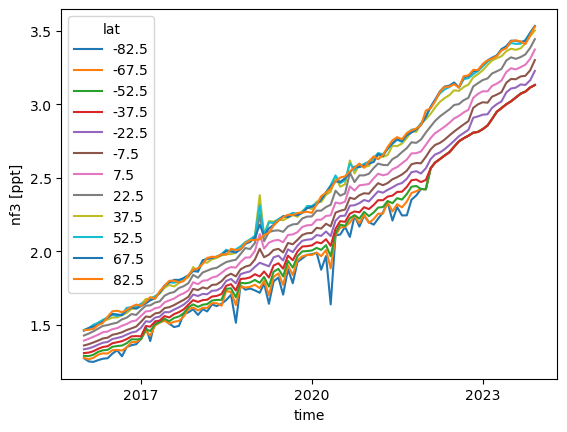

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

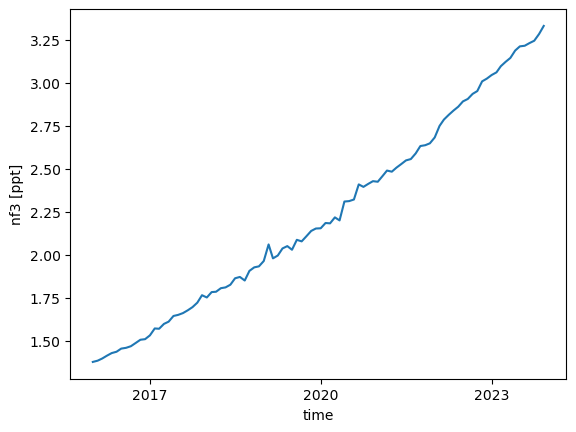

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

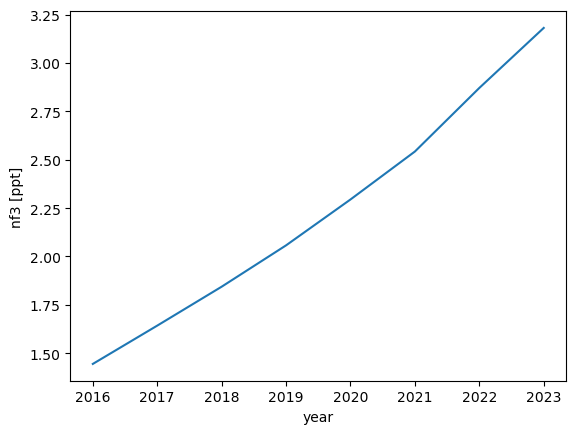

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[-0.4067679637035101 -0.6485717039372253 -0.300911969133077 -0.4230458380457883 0.3581711758183788 -0.02500824757068854 -0.09907832495439436 0.03588940776746237] [-0.3678125109647298 -0.3701445002964471 0.02293068926867364 0.5413605669530043 -0.39658109282343124 -0.14960030018966775 0.16532767882358346 -0.04669058849213976] [-0.3265012781958444 -0.0806474992345414 0.19967996610486033 0.25793572628939415 -0.0418721055713214 0.3424724181687079 0.1917106310465586 0.0026770001110806418] [-0.2759712298176819 0.23229195874394717 0.48408302953502674 0.03633745387962103 0.5589197125288923 0.010854804681523821 -0.04647810508770492 -0.22513661788141395] [-0.1757010223159329 0.19686613423372037 0.15816353730629393 -0.1881355052921051 -0.10314913685182017 -0.3449445914946355 -0.028416097260998734 0.6158313935081744] [-0.07396073109394412 0.1265691367442366 -0.08730721980143345 -0.2074965847782354 -0.3668996221746388 -0.18748496478230353 -0.48668448642109036 -0.1353252440623789] [0.0503693841599409 0.0822950796606763 -0.17679645211997905 -0.22881200164548304 -0.19857252301858036 0.27781007604757274 0.053607013684630396 -0.5659610213495141] [0.18059996162806438 0.03723485660186047 -0.2789000696613143 -0.14915245437656705 -0.02465087056183695 0.35911858331031266 0.49190740323116183 0.3507984507721909] [0.31002791118861217 -0.02283749910052286 -0.3052373597858854 0.2775200817426394 0.3615961849398039 -0.5584879401759962 0.269827659260691 -0.18359897333278652] [0.34661664151569993 -0.2020788364377856 0.007116384691625535 0.3355599618919049 0.23249400143861784 0.40408493631945214 -0.48390048222367027 0.2553297210190049] [0.33774651307136705 -0.372217480175223 0.14582896715625485 0.06741292532795742 -0.1211352332736397 -0.13829840464650725 -0.22537719558833186 -0.019850007686648508] [0.3386192657849342 -0.3728887563420697 0.6152646878138537 -0.3360001963142916 -0.1245774114303553 -0.07062089975587194 0.28923981739076443 -0.07489824032719292]]
Units,ppt
Magnitude,[[0.32002609233427165 0.022669869549542476 0.007600471002197733 -0.00170492269574259 -0.0011412579308239957 0.0027056197759810913 0.001829537425890921 -0.00019281539926045392] [0.3335543013340722 0.0048311855847729575 -0.002853485278224881 -0.00560352083520401 0.005081986671091164 -0.003080800147891505 0.0010958323823114333 0.0001649791650741175] [0.42904778981884323 0.024375909794203544 0.007356644537270958 0.00027481950522831447 0.0009506001600358119 0.0014370493739171732 -0.00037245178560250925 0.0008154841336398428] [0.5191726810801345 0.06730445934812407 -0.024297511745127197 0.002972546618555998 0.0032435025679361297 0.0009203282834590776 -0.00033195295266476435 -0.00016978818472803905] [0.5241639816795868 0.03683371532767961 0.009514087354210464 0.008579568355557125 -0.004449989476767774 -0.002311896870981808 0.0003084830868349778 -4.474627938730682e-05] [0.5862307110673278 0.03573688372116346 0.013981629060882333 -0.007568920124100399 -0.0007697014400556768 -0.00010399587910169324 -0.001178048663109846 -0.0003293645444544262] [0.6110978145911714 -0.09434566956249892 0.006717417238016154 0.004534221228958336 0.005251666037197847 0.0006437037555598999 -0.0002113114339939575 -0.0001740119442636535] [0.563488328767586 -0.06543172343019972 -0.01652333381842442 -0.0036864959493859667 -0.006827491602334731 -9.443719022477478e-05 6.950585822073294e-05 0.00012035828426506975]]
Units,dimensionless


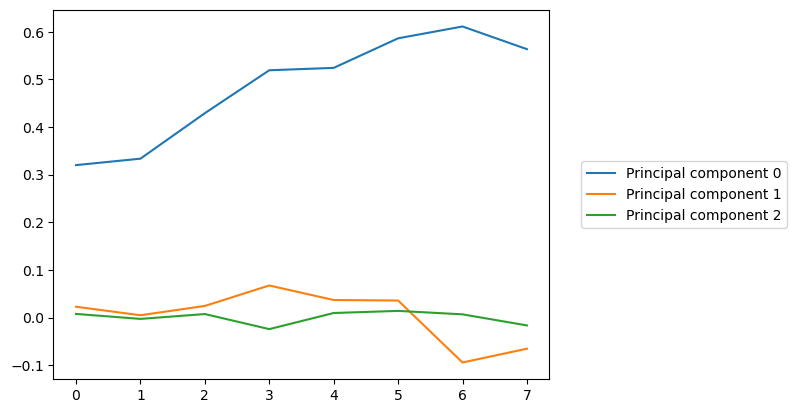

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

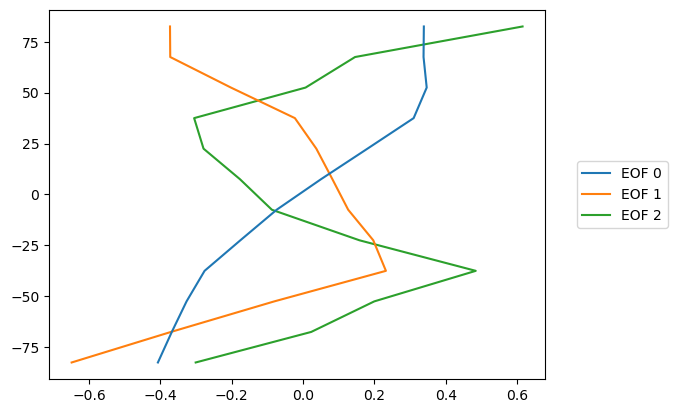

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

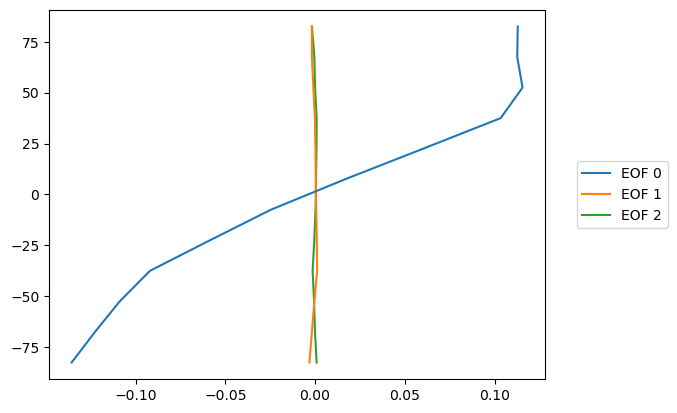

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[-0.4067679637035101] [-0.3678125109647298] [-0.3265012781958444] [-0.2759712298176819] [-0.1757010223159329] [-0.07396073109394412] [0.0503693841599409] [0.18059996162806438] [0.31002791118861217] [0.34661664151569993] [0.33774651307136705] [0.3386192657849342]]
Units,ppt
Magnitude,[[0.32002609233427165] [0.3335543013340722] [0.42904778981884323] [0.5191726810801345] [0.5241639816795868] [0.5862307110673278] [0.6110978145911714] [0.563488328767586]]
Units,dimensionless


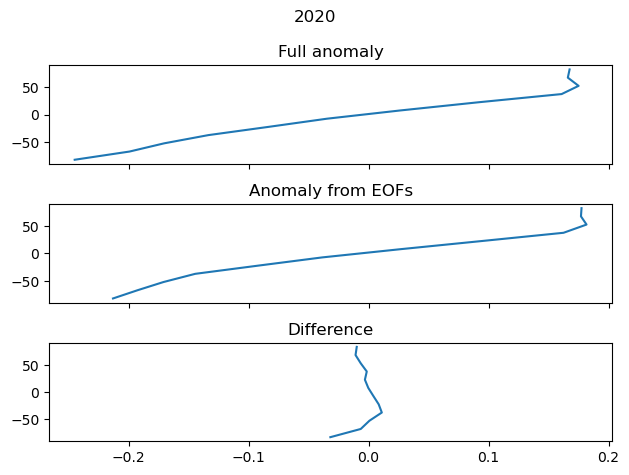

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                       | 0/96 [00:00<?, ?it/s]

Calculating output values: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 96/96 [00:00<00:00, 12080.08it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                       | 0/96 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                       | 0/96 [00:00<?, ?it/s]

Calculating output values: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 96/96 [00:00<00:00, 18558.01it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                       | 0/96 [00:00<?, ?it/s]

Calculating output values: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 96/96 [00:00<00:00, 19409.65it/s]

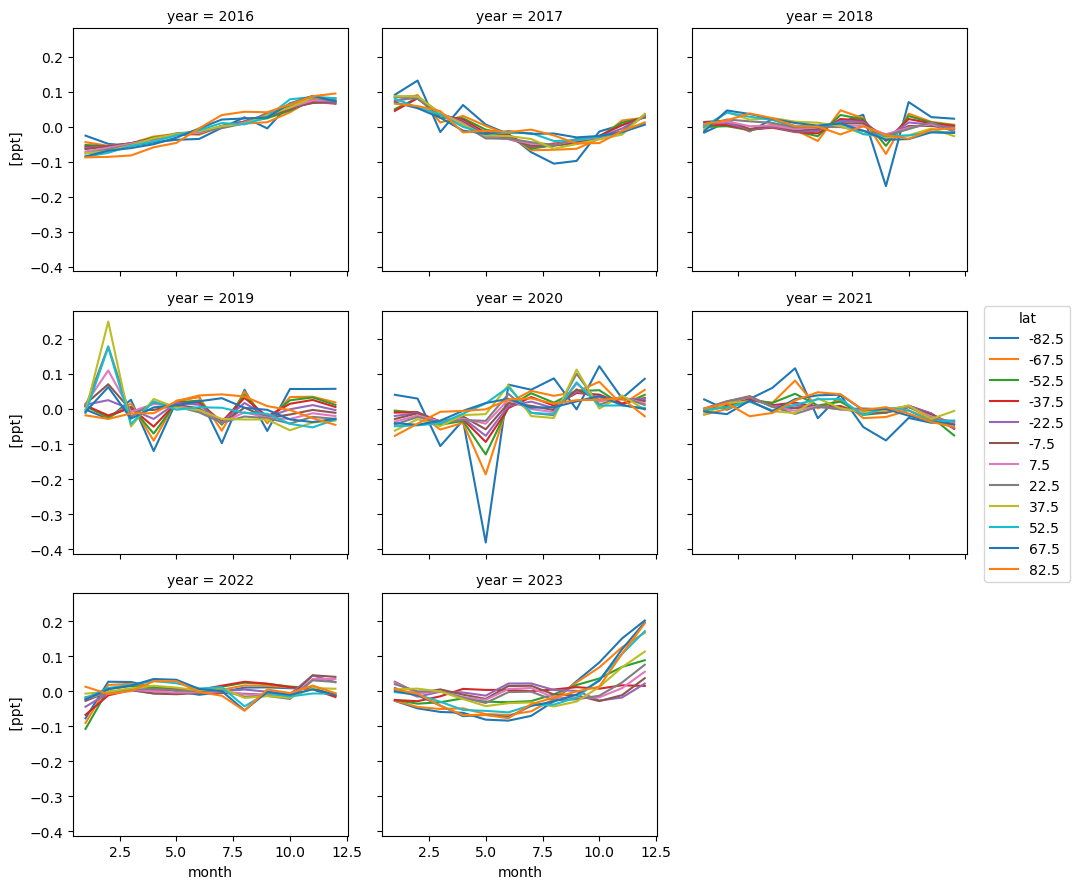

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

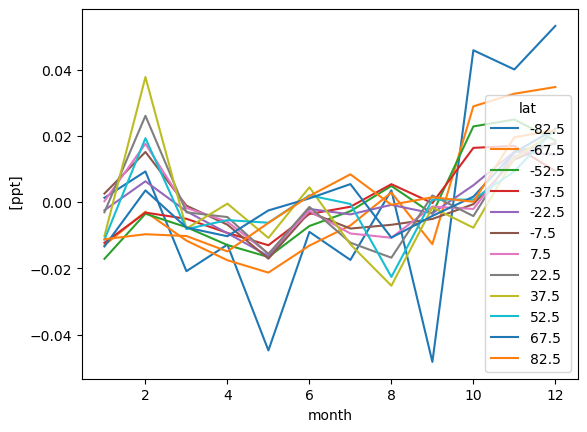

In [22]:
seasonality.plot.line(hue="lat")

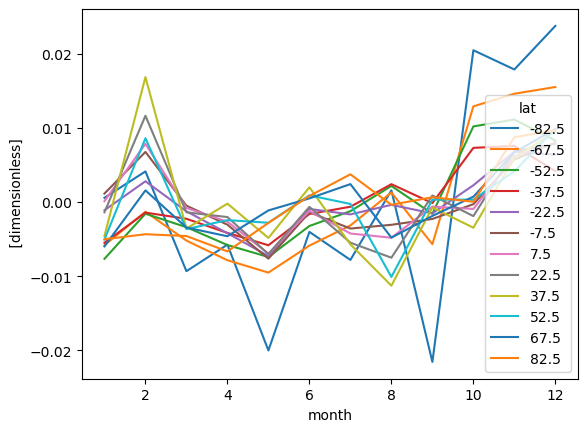

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[1.444790381671398 1.6426915436190885 1.843798620600433 2.057406851137141 2.2944686413667568 2.542255673714907 2.8706950279719696 3.1808524926121016]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[-0.4067679637035101] [-0.3678125109647298] [-0.3265012781958444] [-0.2759712298176819] [-0.1757010223159329] [-0.07396073109394412] [0.0503693841599409] [0.18059996162806438] [0.31002791118861217] [0.34661664151569993] [0.33774651307136705] [0.3386192657849342]]
Units,ppt
Magnitude,[[0.32002609233427165] [0.3335543013340722] [0.42904778981884323] [0.5191726810801345] [0.5241639816795868] [0.5862307110673278] [0.6110978145911714] [0.563488328767586]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.0005839360544183633 0.0041412284982465485 -0.009330550719071327 -0.005744988174398108 -0.02003508127272936 -0.004022721052125621 -0.00781127554328796 0.0015865747681922655 -0.02158784157639933 0.020509324436469887 0.01791482072475904 0.023796740415840394] [-0.005820596378796308 -0.0012999363400448363 -0.00520248917023871 -0.0078522364534928 -0.00952479611978239 -0.005875962533191465 -0.0031534258803711914 0.0013000639325342737 -0.005684666011855187 0.012931401727418688 0.014638410070857501 0.01554434087787229] [-0.0076613105737957776 -0.0015708300157585991 -0.0033890202728661654 -0.005801577557626084 -0.007415256442283372 -0.003228205502536087 -0.0012247178352902482 0.0021798251977608474 -0.0015722063989470297 0.010221342922706898 0.011152623751100139 0.008309309216563678] [-0.005495656437788451 -0.0014172848614765077 -0.002254218046132158 -0.004159657440342376 -0.005829217161161841 -0.0016034425523232926 -0.0006290450565248815 0.0024213368848937443 -0.00013239952369596705 0.007325676268411003 0.007590225057965361 0.00418353607376646] [-0.0011006514671613235 0.0028133641369036642 -0.0012470020130789638 -0.004202267079359419 -0.007284711734133218 -0.0009249280028826127 -0.0016609065576500943 -0.0003727246550909698 -0.0015201831392005565 0.00227353488315303 0.006822579303318904 0.006403718577573074] [0.0011547254199384773 0.006774255663158444 -0.0004833722685740885 -0.0030499525513331825 -0.007640475449462147 -0.0013649921650376834 -0.003573911905701204 -0.003066163582213921 -0.0022780135271538897 -0.0002811261198998908 0.0057567137571780235 0.008052151257161128] [0.00012365344084526127 0.00787834544425653 -0.0007916669042316442 -0.002653228189153288 -0.006957204937848757 -0.0011890719868061614 -0.004241028510756531 -0.004814098402741845 -0.0006077084771538381 -0.0009244226918634917 0.006206499901233806 0.007969802807934849] [-0.0013712675409330113 0.011662915110801945 -0.0013785655134396987 -0.002020765486854389 -0.007018149652188089 -0.0006486076783973934 -0.005482671246824965 -0.0075082423197831765 0.0008960558292059402 -0.001890796525420843 0.006900947287302891 0.007859061154966818] [-0.004579949017376899 0.01689266475959785 -0.003577495747335134 -0.00020892234818605952 -0.004838880688194215 0.0020002631107012 -0.005709384204046351 -0.011292008327565696 -0.0007210916045960598 -0.0034596101703376473 0.005928521955674335 0.009565890455968] [-0.005065403485942341 0.008629139226902928 -0.003644829902750163 -0.0024372115961671125 -0.002788767863175248 0.0009116333418693882 -0.00025157189357449675 -0.010105762001857036 0.0003387603290953848 0.0003328370359922355 0.00416884991161759 0.00991241918792118] [-0.005986851135487902 0.0015806512227277863 -0.0034364282470030296 -0.00461427313966447 -0.0011244280535140524 0.0005026308659737615 0.002430683936512312 -0.004802195124197393 -0.0018662985476539916 0.0007303739548370331 0.006710418642997253 0.009875857951048932] [-0.005013221843068056 -0.004340054298168511 -0.0045824334487563935 -0.006658647343667446 -0.002808938183074037 0.0008233376648232538 0.003756344876345017 -0.0003609396360564321 0.0006547481660822653 4.6291374120716856e-05 0.008756697333811429 0.00972694799832349]]
Units,dimensionless
